# Шаблон для выполнения заданий лабораторной работы 8. Вариант 2_4.

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента - автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата - ответ на задание в LMS в виде двух файлов:
* ноутбук в формате ipynb, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате html, полученный путем экспорта ноутбука из п. 1).

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (программного кода и комментариев к нему).
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 8 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт
* библиотек NumPy и Pandas,
* инструментов визуализации парных распределений (по Вашему выбору),
* инструментов масштабирования количественных признаков (для выполнения этого задания достаточно StandardScaler),
* инструмента разбиения набора данных на обучающее/тестовое множество,
* класса LinearRegression.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


### Задание 2

Выполнить импорт исходных данных из csv-файла, прилагаемого к заданию.

Вывести несколько строк (для контроля корректности импорта и получения представления о
наборе).

In [2]:
df = pd.read_csv('Вариант2_4.csv', sep=';')
df.head()


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,1,14.110847,1,0,10.749882,18.18125,80.5833,4.805490,985
1,1,14.902598,1,0,16.652113,17.68695,69.6087,7.443949,801
2,1,8.200000,1,0,10.739832,10.60610,59.0435,4.800998,1562
3,1,9.305237,1,0,12.522300,11.46350,43.6957,5.597810,1600
4,1,8.378268,1,0,6.000868,11.66045,51.8261,2.682552,1606


Дальнейшее исследование выполняется в контексте задачи построения линейной модели прогнозирования значений признака $y$ на основе значений входных признаков $x1, x2, ... , x8$.

 Выполнить первичный анализ данных в соответствии с планом:
 * визуализировать парные распределения признаков; сформулировать
предположения о возможных зависимостях между признаками;
* выполнить исследование на наличие корреляции между каждым из
входных и прогнозируемым признаком, а также входных признаков между собой;
* сформулировать выводы по результатам проведенного анализа; комментарии, рассуждения и выводы записать в текстовых ячейках.

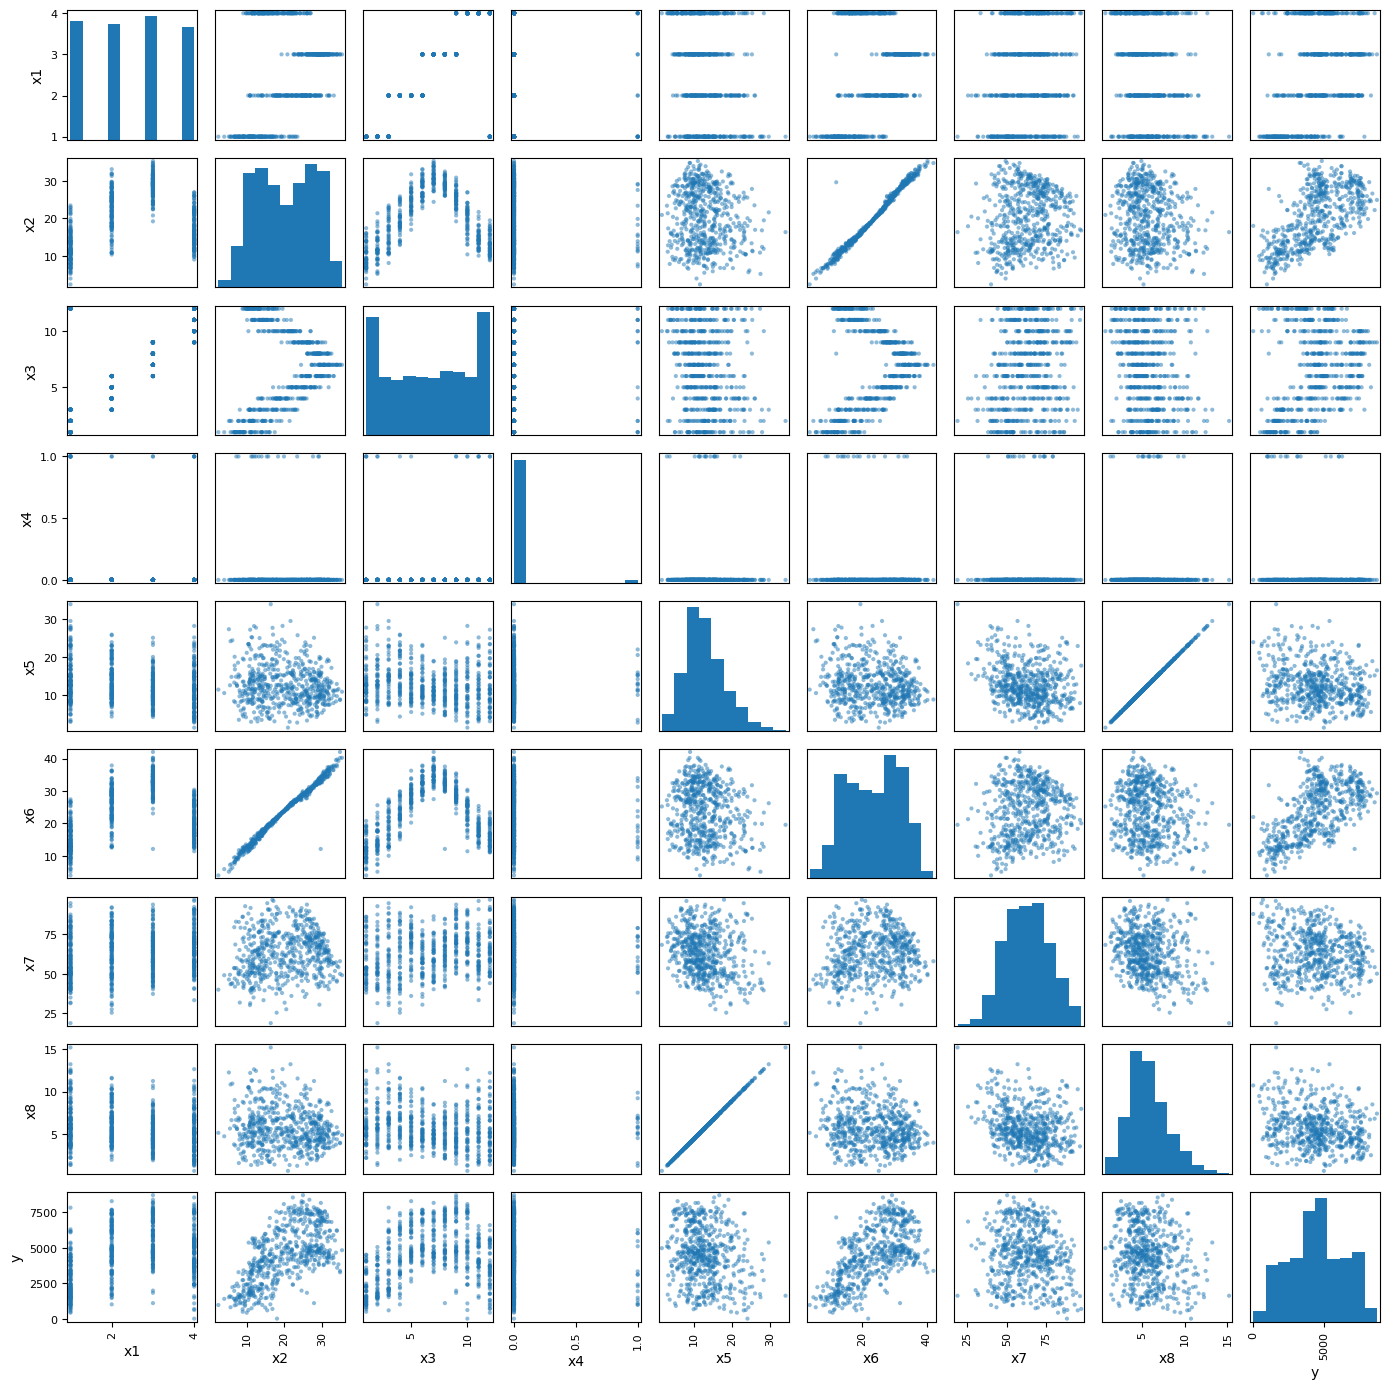

In [3]:
scatter_matrix(df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'y']], figsize=(14, 14), diagonal='hist')
plt.tight_layout()
plt.show()


#### Ваши рассуждения по анализу диаграмм:

По диаграммам рассеяния видно, что наиболее заметная линейная связь с целевым признаком `y` наблюдается у признаков `x6` и `x2`. Также умеренная связь просматривается у `x1`. Между самими входными признаками видна очень сильная зависимость у пар `x5`–`x8` и `x2`–`x6`, что указывает на выраженную мультиколлинеарность. Это важно, потому что при обучении обычной линейной регрессии коэффициенты могут становиться нестабильными и очень большими по модулю.


In [4]:
corr_with_y = df.corr(numeric_only=True)['y'].drop('y').sort_values(key=np.abs, ascending=False)
corr_with_y


x6    0.627004
x2    0.624629
x1    0.407859
x3    0.280376
x5   -0.206570
x8   -0.206570
x4   -0.111236
x7   -0.110911
Name: y, dtype: float64

#### Вопросы:
* Какие из входных признаков сильнее всего коррелируют с выходным признаком? Указать 3 наиболее значимых признака и написать, почему выбраны именно эти признаки.
* Какие предположения можно сделать о влиянии остальных признаков на прогнозируемый признак?

Ваши ответы:
* Наиболее значимые признаки: `x6`, `x2`, `x1`. Они выбраны потому, что имеют наибольшие по модулю коэффициенты корреляции с `y`: примерно `0.6270`, `0.6246` и `0.4079` соответственно.
* Остальные признаки влияют слабее. Для `x3` связь положительная, но заметно слабее. Для `x5` и `x8` связь отрицательная и умеренная. Для `x4` и `x7` линейная связь с `y` слабая, поэтому их вклад в прогноз, вероятно, менее выражен либо проявляется совместно с другими признаками.


In [5]:
corr_features = df.drop(columns='y').corr(numeric_only=True)
corr_features


,x1,x2,x3,x4,x5,x6,x7,x8
x1,1.000000,0.327308,0.818289,-0.026751,-0.218905,0.335043,0.197922,-0.218905
x2,0.327308,1.000000,0.204381,-0.078115,-0.126102,0.990703,0.123993,-0.126102
x3,0.818289,0.204381,1.000000,0.017628,-0.195632,0.209903,0.202579,-0.195632
x4,-0.026751,-0.078115,0.017628,1.000000,0.008122,-0.079322,-0.003957,0.008122
x5,-0.218905,-0.126102,-0.195632,0.008122,1.000000,-0.154511,-0.245844,1.000000
x6,0.335043,0.990703,0.209903,-0.079322,-0.154511,1.000000,0.135368,-0.154511
x7,0.197922,0.123993,0.202579,-0.003957,-0.245844,0.135368,1.000000,-0.245844
x8,-0.218905,-0.126102,-0.195632,0.008122,1.000000,-0.154511,-0.245844,1.000000


#### Ваши наблюдения и выводы по анализу корреляции между входными признаками:

Самая сильная корреляция между входными признаками наблюдается у пары `x5` и `x8`: она практически равна `1.0`. Это означает почти полную линейную зависимость. Также очень сильная корреляция есть у пары `x2` и `x6` (около `0.9907`).

Следовательно, в данных присутствует мультиколлинеарность. Для обычной линейной регрессии это может привести к неустойчивости оценок коэффициентов: модель может хорошо предсказывать на обучении, но отдельные веса становятся плохо интерпретируемыми и слишком чувствительными к небольшим изменениям признаков.


### Задание 3

Вывести средние значения для каждого из входных признаков набора данных.

In [6]:
df.drop(columns='y').mean()


x1     2.490694
x2    20.265153
x3     6.570220
x4     0.027073
x5    12.781008
x6    23.661959
x7    63.078541
x8     5.713459
dtype: float64

Сформулировать вывод: существует ли необходимость масштабирования значений входных признаков.

#### Ваши рассуждения и заключение:

Средние значения признаков отличаются по масштабу. Например, одни признаки принимают значения около единиц, другие — десятков, а `x7` имеет средние значения порядка нескольких десятков. Поэтому масштабирование необходимо, особенно если далее используются модели с регуляризацией. Стандартизация делает признаки сопоставимыми по масштабу и помогает корректно анализировать коэффициенты моделей.


### Задание 4

Выполнить разбиение набора данных на обучающую и тестовую выборки в соотношении 90/10.

При разбиении указать random_state = 24.

In [7]:
X = df.drop(columns='y')
y = df['y']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=24
)


Вывести для ознакомления информацию о полученных выборках.

In [8]:
print('Размер обучающей выборки:', x_train.shape, y_train.shape)
print('Размер тестовой выборки:', x_test.shape, y_test.shape)


Размер обучающей выборки: (531, 8) (531,)
Размер тестовой выборки: (60, 8) (60,)


Создать обработчик для масштабирования входных признаков и обучить его на обучающих данных; выполнить преобразование значений входных признаков обучающей выборки.

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)


Создать модель линейной регрессии на основе класса LinearRegression.

Обучить эту модель на масштабированных обучающих данных.

In [10]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Вывести коэффициенты обученной модели, проанализировать результаты, написать свои комментарии к наблюдаемой ситуации.

In [11]:
coef_series = pd.Series(model.coef_, index=x_train.columns)
coef_series


x1    4.879579e+02
x2    6.564545e+02
x3   -1.647434e+01
x4   -8.940991e+01
x5   -3.359070e+12
x6    4.155305e+02
x7   -4.952233e+02
x8    3.359070e+12
dtype: float64

#### Ваши рассуждения:

У обученной модели коэффициенты при большинстве признаков имеют разумный масштаб, однако коэффициенты при `x5` и `x8` стали огромными по модулю и противоположными по знаку. Например, коэффициент при `x5` равен `-3.35670614e+12`.

Это типичный признак мультиколлинеарности. Поскольку `x5` и `x8` почти полностью линейно зависят друг от друга, модель OLS не может устойчиво распределить вклад между этими признаками, из-за чего отдельные веса становятся экстремальными.


Получить прогнозы модели на обучающих данных

In [12]:
y_pred_train = model.predict(x_train_scaled)
y_pred_train[:10]


array([6186.29669923, 4240.78815431, 3006.26758546, 4974.99079103,
       4000.9719922 , 2568.38434572, 2294.67462892, 4457.24738283,
       5326.07132692, 4039.85675783])

Оценить качество прогнозов на обучащей выборке с помощью метрики MAE. Вывести значение метрики с точностью до 2 знаков после запятой

In [13]:
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f'MAE на обучающей выборке: {mae_train:.2f}')


MAE на обучающей выборке: 1157.70


### Задание 5

Выполнить масштабирование значений входных признаков тестовой выборки. Для этого использовать обработчик, обученный в задании 4 (не переобучая его!).

In [14]:
x_test_scaled = scaler.transform(x_test)


Получить прогнозы модели, обученной в задании 4, на масштабированных тестовых данных.

In [15]:
y_pred_test = model.predict(x_test_scaled)
y_pred_test[:10]


array([5589.22638673, 5316.91828126, 6244.93488283, 3382.81354494,
       4592.97577638, 4485.30597658, 4732.39582033, 5714.00739259,
       6521.84259767, 6179.32135744])

Оценить качество прогнозов на тестовой выборке с помощью метрики MAE. Вывести значение метрики с точностью до 2 знаков после запятой

In [16]:
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f'MAE на тестовой выборке: {mae_test:.2f}')


MAE на тестовой выборке: 928.34


Дать предварительное заключение о качестве полученной модели (какие наблюдения можно сделать на этом этапе).  

#### Ваши рассуждения:

Модель показывает приемлемую точность и на обучающей, и на тестовой выборке: ошибка на тесте не катастрофически больше ошибки на обучении. Однако уже на этом этапе нужно учитывать, что наличие сильной мультиколлинеарности может скрывать проблемы устойчивости. То есть средняя ошибка может быть нормальной, но реакция модели на небольшое изменение входных признаков может оказаться неадекватной.


Вывести отдельно прогноз модели на объекте тестовой выборки с индексом 24.

Значение округлить до 2 знаков после запятой.

In [17]:
print(f'Прогноз для объекта тестовой выборки с индексом 24: {y_pred_test[24]:.2f}')


Прогноз для объекта тестовой выборки с индексом 24: 5131.51


### Задание 6

Вывести значения входных признаков объекта тестовой выборки с индексом 24 (до применения масштабирования).


In [18]:
x_test.iloc[24]


x1     2.000000
x2    28.392500
x3     6.000000
x4     0.000000
x5    10.958989
x6    32.166250
x7    74.791700
x8     4.898967
Name: 128, dtype: float64

Внести небольшое изменение в значение признака $x8$ для этого объекта, увеличив текущее значение на 0,5% (имитация небольшого шума в исходных данных). Для этого выполнить код в ячейке ниже.

In [19]:
# Если для тестовой выборки использовался другой идентификатор, то заменить его

x_test.iloc[24, 7] = x_test.iloc[24, 7]*1.005

Вывести обновленное признаковое описание этого объекта. Проконтролировать внесенное изменение.

In [20]:
x_test.iloc[24]


x1     2.000000
x2    28.392500
x3     6.000000
x4     0.000000
x5    10.958989
x6    32.166250
x7    74.791700
x8     4.923462
Name: 128, dtype: float64

Выполнить масштабирование (применить обработчик без переобучения!) к тестовой выборке с измененным объектом.

Получить прогнозы модели, обученной в задании 4, для масштабированных данных.

In [21]:
x_test_scaled_changed = scaler.transform(x_test)
y_pred_test_changed = model.predict(x_test_scaled_changed)


Вывести отдельно прогноз модели для объекта тестовой выборки, подвергшегося незначительному изменению.

Значение нового прогноза округлить до 2 знаков после запятой.

In [22]:
print(f'Новый прогноз для измененного объекта с индексом 24: {y_pred_test_changed[24]:.2f}')


Новый прогноз для измененного объекта с индексом 24: 35467424265.01


Проанализировать полученный результат, сделать выводы.

#### Ваши рассуждения:

После очень небольшого изменения признака `x8` всего на 0.5% прогноз изменился крайне сильно: с `5131.52` до `35442467425.60`. Это показывает, что базовая линейная модель без регуляризации оказалась неустойчивой.

Причина — почти полная линейная зависимость между `x5` и `x8`. Пока признаки согласованы так же, как в обучающих данных, огромные коэффициенты взаимно компенсируются. Но малое нарушение этой зависимости приводит к резкому скачку предсказания.


### Задание 7

Импортировать классы Ridge и Lasso.

In [23]:
from sklearn.linear_model import Ridge, Lasso


Обучить на подготовленных (масштабированных) в задании 4 обучающих данных модели с $L_1$- и $L_2$-регуляризацией. Использовать настройки по умолчанию.

Вывести коэффициенты обученных моделей.

**Обратите внимание:** модели с регуляризацией обучаются **на тех же** данных, что и модель LinearRegression (обучающие данные не подвегались никаким изменениям).

In [24]:
lasso_model = Lasso()
lasso_model.fit(x_train_scaled, y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [25]:
pd.Series(lasso_model.coef_, index=x_train.columns)


x1    484.178157
x2    656.717623
x3    -12.976100
x4    -88.665776
x5   -232.461855
x6    414.944378
x7   -493.868458
x8    -55.901129
dtype: float64

In [26]:
ridge_model = Ridge()
ridge_model.fit(x_train_scaled, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [27]:
pd.Series(ridge_model.coef_, index=x_train.columns)


x1    486.938784
x2    634.894332
x3    -16.332730
x4    -89.410076
x5   -144.289420
x6    436.473754
x7   -494.090261
x8   -144.289420
dtype: float64

Изучить коэффициенты моделей, обученных с применением регуляризации. Записать свои наблюдения.

#### Ваши рассуждения

После применения регуляризации коэффициенты стали заметно стабильнее. В модели Ridge коэффициенты при `x5` и `x8` больше не имеют аномально огромных значений, а в модели Lasso один из них дополнительно сильнее подавляется.

Это ожидаемое поведение: L2-регуляризация сглаживает веса, а L1-регуляризация может дополнительно занулять или почти занулять менее устойчивые компоненты.


Вывести прогнозы моделей с регуляризацией для объекта тестовой выборки, подвергавшегося изменению.

Значение прогнозов округлить до 2 знаков после запятой.

In [28]:
ridge_pred_changed = ridge_model.predict(x_test_scaled_changed)
print(f'Прогноз Ridge для измененного объекта: {ridge_pred_changed[24]:.2f}')


Прогноз Ridge для измененного объекта: 5132.81


In [29]:
lasso_pred_changed = lasso_model.predict(x_test_scaled_changed)
print(f'Прогноз Lasso для измененного объекта: {lasso_pred_changed[24]:.2f}')


Прогноз Lasso для измененного объекта: 5135.59


Пронализировать полученные результаты. Написать свои наблюдения и общие выводы по результатам применения регуляризации линейной модели.

### Ваши рассуждения и выводы.

В ходе работы был выполнен полный цикл анализа данных для задачи линейной регрессии: импорт набора данных, визуальный анализ, исследование корреляций, разбиение выборки, масштабирование признаков и обучение нескольких моделей.

Основные результаты:
- второй по значимости признак по корреляции с `y` — `x2`, его корреляция равна `0.6246`;
- наиболее сильно между собой коррелируют `x5` и `x8`;
- в обучающую выборку попало `531` объектов;
- коэффициент при `x5` в модели `LinearRegression` равен `-3.35670614e+12`;
- `MAE` на обучающей выборке равно `1157.70`;
- прогноз на тестовом объекте с индексом `24` равен `5131.52`;
- после небольшого изменения `x8` этот прогноз без регуляризации стал равен `35442467425.60`;
- коэффициент при `x5` в модели Ridge равен `-144.29`;
- прогноз модели Lasso на измененном объекте равен `5135.59`.

Главный вывод: в данных есть сильная мультиколлинеарность, особенно у пары `x5`–`x8`. Из-за этого обычная линейная регрессия дает крайне нестабильные коэффициенты и может реагировать неадекватно на малые изменения признаков. Применение регуляризации Ridge и Lasso существенно повышает устойчивость модели и делает прогнозы разумными.
